# Visualizing the time-course datasets

This notebook provides a descriptive view of the datasets shipped with the repository. It focuses on sample size, data quality, population-level dynamics, and single-cell heterogeneity. The plots do not define bursts or test biological hypotheses; they expose structures that can motivate a later modeling or annotation strategy.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deeplearning_examples.io import (
    load_smad_timecourses,
    load_stimulation_timecourses,
)

RANDOM_SEED = 42
CONDITION_COLORS = {
    "control": "#4C78A8",
    "TGF-beta high": "#F58518",
    "GDF11 high": "#54A24B",
    "stimulation 100 pM": "#B279A2",
}

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Load and inventory

The SMAD files contain an explicit time vector and three experimental conditions. The MATLAB files contain trajectories only and are therefore shown against their frame index. Assigning physical time units to those frames would require metadata not stored in the files.

In [2]:
smad_data = load_smad_timecourses()
stimulation_data = load_stimulation_timecourses()

smad_conditions = {
    "control": smad_data.control,
    "TGF-beta high": smad_data.tgfb_high,
    "GDF11 high": smad_data.gdf11_high,
}
all_datasets = {**smad_conditions, "stimulation 100 pM": stimulation_data}

def summarize_dataset(name: str, trajectories: np.ndarray) -> dict[str, object]:
    finite_values = trajectories[np.isfinite(trajectories)]
    return {
        "dataset": name,
        "trajectories": trajectories.shape[0],
        "timepoints": trajectories.shape[1],
        "missing values": int(np.isnan(trajectories).sum()),
        "minimum": float(finite_values.min()),
        "median": float(np.median(finite_values)),
        "maximum": float(finite_values.max()),
    }

dataset_summary = pd.DataFrame(
    [summarize_dataset(name, trajectories) for name, trajectories in all_datasets.items()]
).set_index("dataset")
dataset_summary.round(3)

,trajectories,timepoints,missing values,minimum,median,maximum
dataset,,,,,,
control,4478,288,0,0.069,0.469,6.896
TGF-beta high,2651,288,0,0.060,0.549,8.467
GDF11 high,2692,288,0,0.056,0.512,6.180
stimulation 100 pM,730,289,0,0.090,0.780,4.313


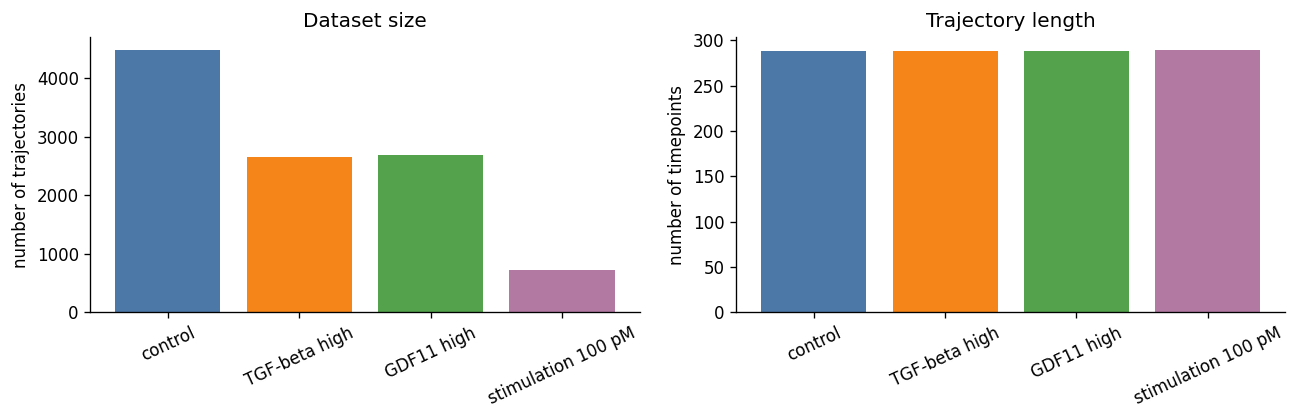

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(11, 3.6))
names = list(all_datasets)
colors = [CONDITION_COLORS[name] for name in names]

axes[0].bar(names, dataset_summary.loc[names, "trajectories"], color=colors)
axes[0].set_ylabel("number of trajectories")
axes[0].set_title("Dataset size")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(names, dataset_summary.loc[names, "timepoints"], color=colors)
axes[1].set_ylabel("number of timepoints")
axes[1].set_title("Trajectory length")
axes[1].tick_params(axis="x", rotation=25)

figure.tight_layout()

## SMAD conditions

The first row shows randomly selected cells and therefore makes cell-to-cell heterogeneity visible. The second row summarizes each population by its median and interquartile range. The latter is more robust to rare high-amplitude events than a mean with a standard deviation.

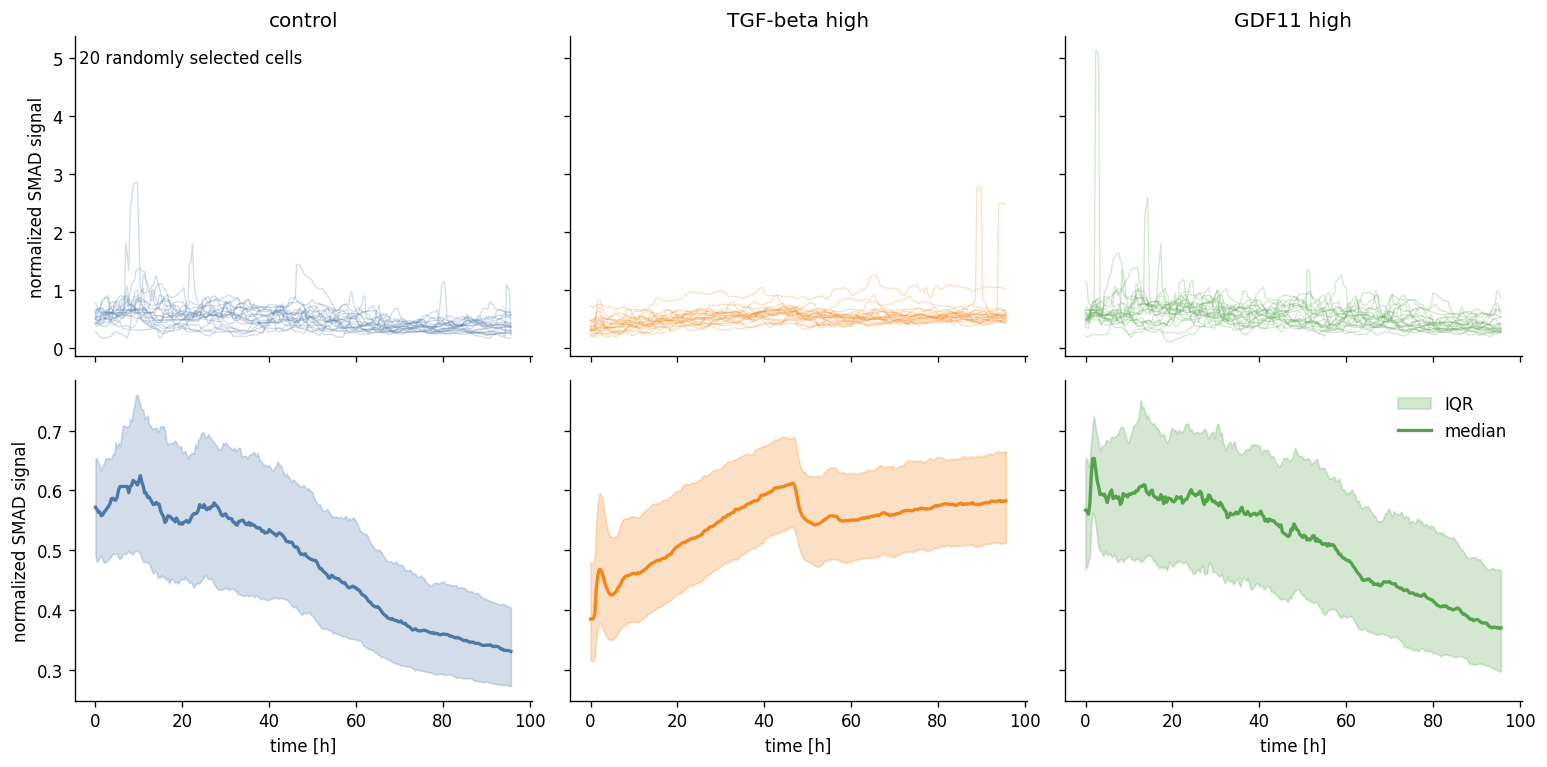

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
time_hours = smad_data.times / 60.0
figure, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True, sharey="row")

for column, (name, trajectories) in enumerate(smad_conditions.items()):
    color = CONDITION_COLORS[name]
    selected = rng.choice(trajectories.shape[0], size=20, replace=False)
    axes[0, column].plot(time_hours, trajectories[selected].T, color=color, alpha=0.25, linewidth=0.8)
    axes[0, column].set_title(name)

    lower, median, upper = np.quantile(trajectories, [0.25, 0.5, 0.75], axis=0)
    axes[1, column].fill_between(time_hours, lower, upper, color=color, alpha=0.25, label="IQR")
    axes[1, column].plot(time_hours, median, color=color, linewidth=2, label="median")
    axes[1, column].set_xlabel("time [h]")

axes[0, 0].set_ylabel("normalized SMAD signal")
axes[1, 0].set_ylabel("normalized SMAD signal")
axes[1, 2].legend(frameon=False)
axes[0, 0].text(0.01, 0.96, "20 randomly selected cells", transform=axes[0, 0].transAxes, va="top")
figure.tight_layout()

### Descriptive trajectory features

The following features compress each trajectory without imposing a burst definition. `baseline` is the median of the first six measurements, corresponding to the first 100 minutes. `peak above baseline` captures amplitude, while temporal standard deviation and mean signal capture variability and sustained activity. These features are correlated and should not be interpreted as independent biological mechanisms.

In [5]:
def trajectory_features(name: str, trajectories: np.ndarray) -> pd.DataFrame:
    baseline = np.median(trajectories[:, :6], axis=1)
    return pd.DataFrame({
        "condition": name,
        "baseline": baseline,
        "peak above baseline": trajectories.max(axis=1) - baseline,
        "temporal standard deviation": trajectories.std(axis=1),
        "mean signal": trajectories.mean(axis=1),
    })

smad_features = pd.concat(
    [trajectory_features(name, trajectories) for name, trajectories in smad_conditions.items()],
    ignore_index=True,
)
smad_features.groupby("condition").describe(percentiles=[0.25, 0.5, 0.75]).round(3)

baseline                       ... mean signal                     
                 count   mean    std    min  ...         25%    50%    75%    max
condition                                    ...                                 
GDF11 high      2692.0  0.575  0.129  0.153  ...       0.462  0.526  0.597  0.930
TGF-beta high   2651.0  0.422  0.157  0.068  ...       0.491  0.551  0.615  1.909
control         4478.0  0.574  0.167  0.151  ...       0.431  0.492  0.555  0.916

[3 rows x 32 columns]

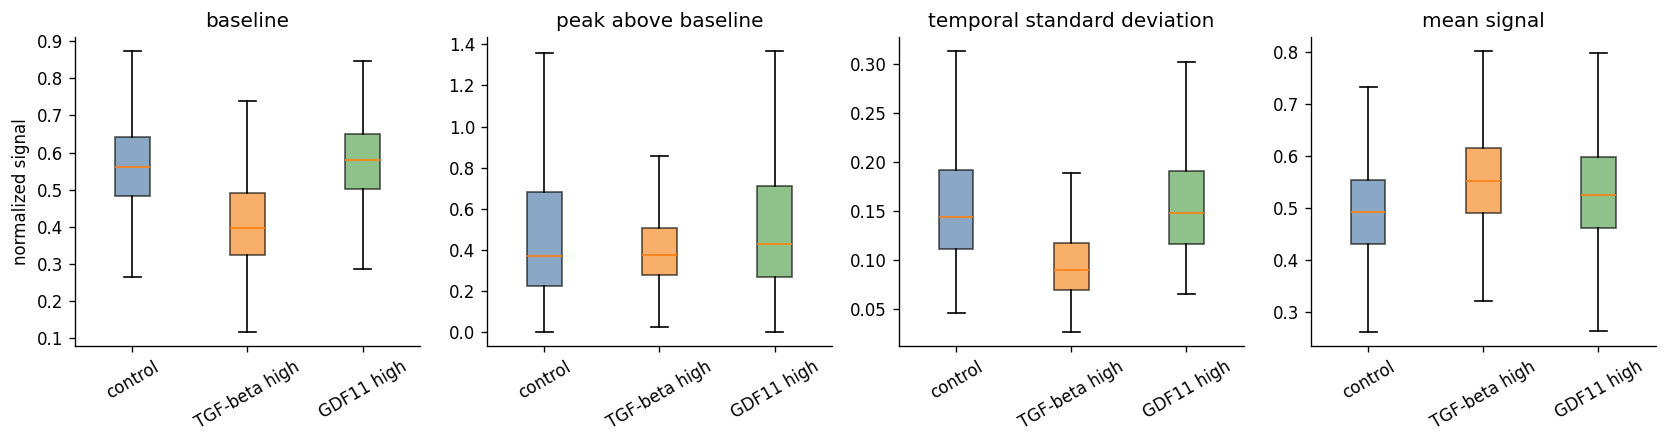

In [6]:
feature_names = [
    "baseline",
    "peak above baseline",
    "temporal standard deviation",
    "mean signal",
]
figure, axes = plt.subplots(1, len(feature_names), figsize=(14, 3.8))
condition_names = list(smad_conditions)

for axis, feature_name in zip(axes, feature_names):
    values = [
        smad_features.loc[smad_features["condition"] == name, feature_name].to_numpy()
        for name in condition_names
    ]
    boxplot = axis.boxplot(values, tick_labels=condition_names, showfliers=False, patch_artist=True)
    for patch, name in zip(boxplot["boxes"], condition_names):
        patch.set_facecolor(CONDITION_COLORS[name])
        patch.set_alpha(0.65)
    axis.set_title(feature_name)
    axis.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("normalized signal")
figure.tight_layout()

## Combined 100 pM stimulation data

The two MATLAB cohorts are combined by the repository's import function. The left panel preserves the raw signal scale. The heatmap subtracts the median of the first four, pre-response frames for each cell and sorts cells by the frame of their largest positive deviation. This makes asynchronous events easier to see, but a local maximum alone is not evidence of a burst.

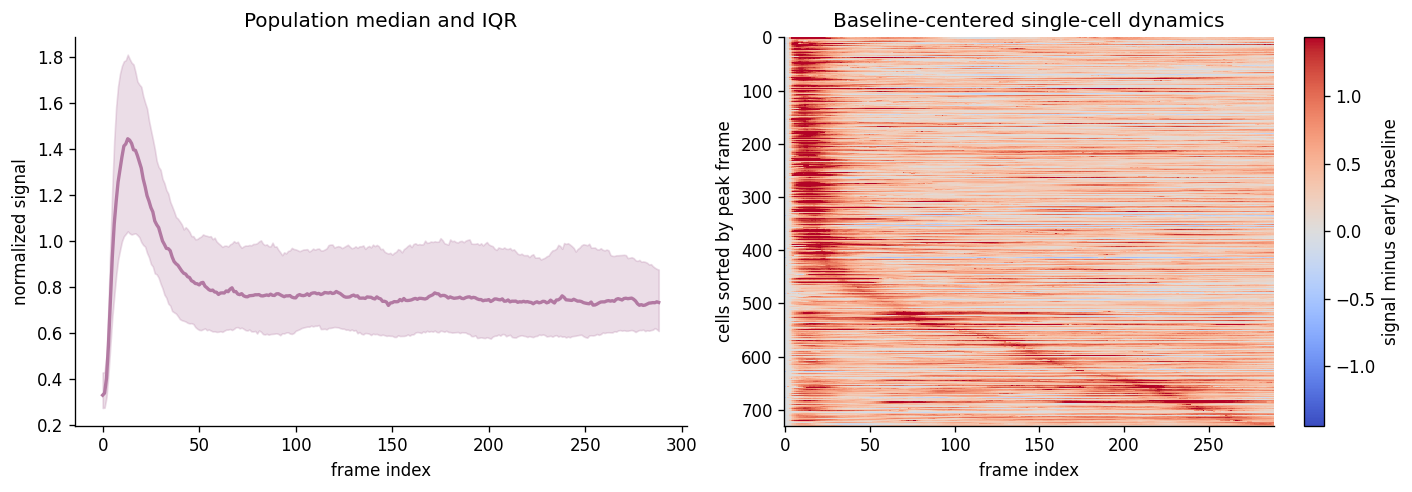

In [7]:
stimulation_baseline = np.median(stimulation_data[:, :4], axis=1, keepdims=True)
stimulation_centered = stimulation_data - stimulation_baseline
peak_frames = np.argmax(stimulation_centered, axis=1)
sorted_cells = np.argsort(peak_frames)

lower, median, upper = np.quantile(stimulation_data, [0.25, 0.5, 0.75], axis=0)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].fill_between(np.arange(stimulation_data.shape[1]), lower, upper, color=CONDITION_COLORS["stimulation 100 pM"], alpha=0.25)
axes[0].plot(median, color=CONDITION_COLORS["stimulation 100 pM"], linewidth=2)
axes[0].set_xlabel("frame index")
axes[0].set_ylabel("normalized signal")
axes[0].set_title("Population median and IQR")

color_limit = np.quantile(np.abs(stimulation_centered), 0.98)
image = axes[1].imshow(
    stimulation_centered[sorted_cells],
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-color_limit,
    vmax=color_limit,
)
axes[1].set_xlabel("frame index")
axes[1].set_ylabel("cells sorted by peak frame")
axes[1].set_title("Baseline-centered single-cell dynamics")
figure.colorbar(image, ax=axes[1], label="signal minus early baseline")
figure.tight_layout()

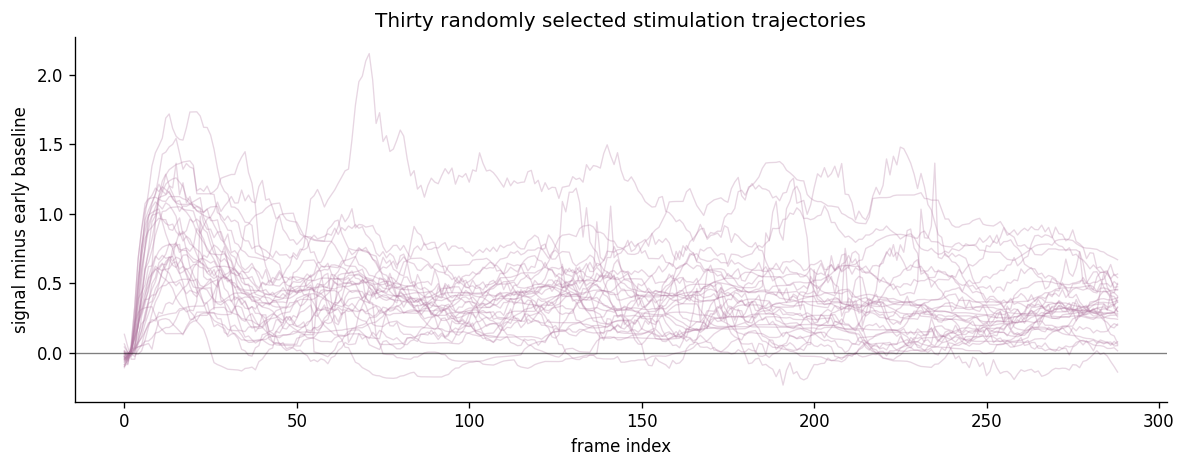

In [8]:
selected = rng.choice(stimulation_data.shape[0], size=30, replace=False)
figure, axis = plt.subplots(figsize=(10, 4))
axis.plot(stimulation_centered[selected].T, color=CONDITION_COLORS["stimulation 100 pM"], alpha=0.3, linewidth=0.8)
axis.axhline(0, color="black", linewidth=0.8, alpha=0.5)
axis.set_xlabel("frame index")
axis.set_ylabel("signal minus early baseline")
axis.set_title("Thirty randomly selected stimulation trajectories")
figure.tight_layout()

## Observations to carry into modeling

* The SMAD classes are imbalanced, so a stratified split and class-aware evaluation are appropriate for classification.
* Population summaries hide asynchronous high-amplitude events. Models intended for burst detection should therefore operate on individual trajectories.
* Baseline differences and temporal events are partially confounded in raw signals. A burst model should either learn a slowly varying baseline explicitly or receive a baseline-normalized view alongside the raw trajectory.
* The visualizations generate hypotheses only. A trainable burst detector still needs either an operational event definition, weak labels, synthetic examples, or a self-supervised objective whose learned states are validated against biological criteria.